In [1]:
import awkward as ak
import glob
import tqdm
import matplotlib.pyplot as plt
import numpy as np
import mplhep
import boost_histogram as bh
import vector
import matplotlib

from enreg.tools import general as g

In [2]:
def to_p4(p4_obj):
    return vector.awk(
        ak.zip(
            {
                "mass": p4_obj.tau,
                "x": p4_obj.x,
                "y": p4_obj.y,
                "z": p4_obj.z,
            }
        )
    )

In [3]:
def load_sample(path, max_files):
    columns = [
        #basic reco inputs
        "reco_jet_p4s",
        "reco_cand_p4s",
        "reco_cand_charge",
        "reco_cand_pdg",

        #advanced reco inputs: tracking variables
        "reco_cand_dz",
        "reco_cand_dz_err",
        "reco_cand_d3",
        "reco_cand_d3_err",
        "reco_cand_z0",
        "reco_cand_z0_err",
        "reco_cand_d0",
        "reco_cand_d0_err",
        "reco_cand_dxy",

        #targets
        "gen_jet_p4s",
        "gen_jet_tau_p4s", #tau visible momentum
        "gen_jet_tau_decaymode",
        "gen_jet_full_tau_p4s", #tau full momentum, for debugging
        "gen_jet_tau_charge"
    ]
    data = []
    for fi in tqdm.tqdm(list(glob.glob(path + "/*.parquet"))[:max_files]):
        ret = ak.from_parquet(fi, columns=columns)
        ret = ak.Array({k: ret[k] for k in ret.fields})
        # ret = ret[to_p4(ret["gen_jet_p4s"]).pt>10]
        data.append(ret)
    data = ak.concatenate(data)
    return data

In [20]:
# data_z = load_sample("/local/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/p8_ee_Z_tautau_ecm91/", -1)
data_z = load_sample("/local/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/p8_ee_ZZ_tautau_ecm365/", -1)

100%|███████████████████████████████████████████████████████████████████| 49/49 [00:10<00:00,  4.67it/s]


In [5]:
data_zh = load_sample("/local/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/p8_ee_Z_qq_ecm91/", -1)

100%|███████████████████████████████████████████████████████████████████| 49/49 [00:16<00:00,  3.04it/s]


In [6]:
data_qq = load_sample("/local/norman/ml-tau/cld/v1.2.3_key4hep_2025-05-29_CLD_f1e8f9/p8_ee_Z_qq_ecm91/", -1)

100%|███████████████████████████████████████████████████████████████████| 49/49 [00:02<00:00, 21.15it/s]


In [21]:
len(data_z), len(data_zh), len(data_qq)

(221012, 828443, 828443)

In [22]:
data_z.fields

['reco_cand_p4s',
 'reco_cand_charge',
 'reco_cand_pdg',
 'reco_jet_p4s',
 'reco_cand_dxy',
 'reco_cand_dz',
 'reco_cand_d3',
 'reco_cand_dz_err',
 'reco_cand_d3_err',
 'reco_cand_d0',
 'reco_cand_z0',
 'reco_cand_d0_err',
 'reco_cand_z0_err',
 'gen_jet_p4s',
 'gen_jet_tau_decaymode',
 'gen_jet_tau_charge',
 'gen_jet_tau_p4s',
 'gen_jet_full_tau_p4s']

In [23]:
# Z
z_gen_tau_p4s = to_p4(data_z.gen_jet_tau_p4s)
z_reco_cand_p4s = to_p4(data_z.reco_cand_p4s)
z_reco_jet_p4s = to_p4(data_z.reco_jet_p4s)
z_gen_tau_decaymode = data_z.gen_jet_tau_decaymode
z_gen_tau_charge = data_z.gen_jet_tau_charge

# ZH
zh_gen_tau_p4s = to_p4(data_zh.gen_jet_tau_p4s)
zh_reco_cand_p4s = to_p4(data_zh.reco_cand_p4s)
zh_reco_jet_p4s = to_p4(data_zh.reco_jet_p4s)
zh_gen_tau_decaymode = data_zh.gen_jet_tau_decaymode
zh_gen_tau_charge = data_zh.gen_jet_tau_charge

# qq
qq_reco_cand_p4s = to_p4(data_qq.reco_cand_p4s)
qq_reco_jet_p4s = to_p4(data_qq.reco_jet_p4s)

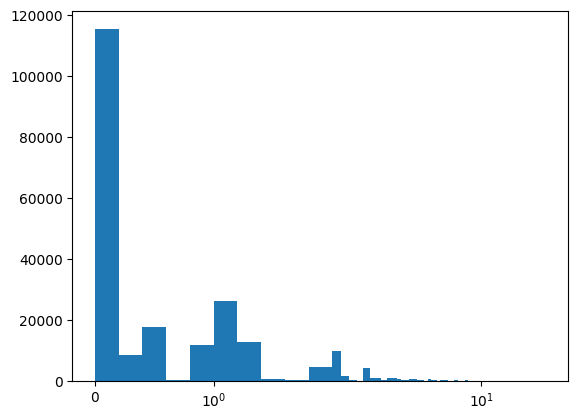

In [24]:
cand_mass = z_reco_cand_p4s.mass
jet_mass = ak.sum(cand_mass, axis=-1)


plt.hist(jet_mass, bins=100)
plt.xscale('symlog')
plt.show()

In [25]:
ak.sum(jet_mass == 0)

np.int64(3272)

In [10]:
def DM_percentages(data):
    """
    Calculate the percentages of decay modes in the given data.
    """
    uniques, counts = np.unique(data, return_counts=True)
    total_count = sum(counts)
    percentages = np.round((counts / total_count) * 100, 2)
    return dict(zip(uniques, percentages))

data_z_percentages = DM_percentages(data_z["gen_jet_tau_decaymode"])
data_zh_percentages = DM_percentages(data_zh["gen_jet_tau_decaymode"])

/scratch/persistent/norman/ipykernel_1991371/3625826684.py:41: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1].set_yscale('log')


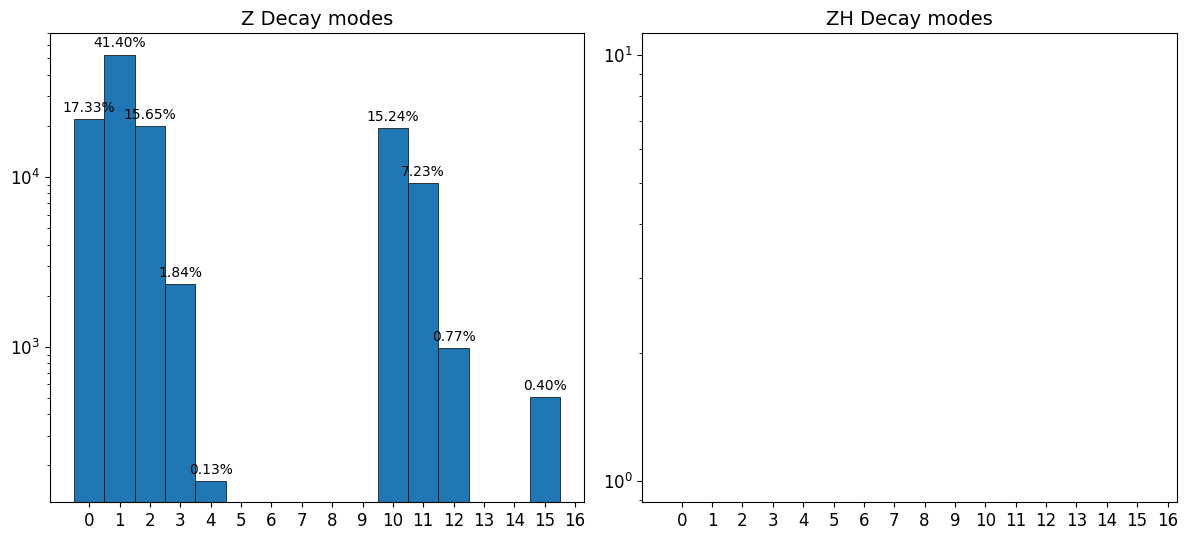

In [11]:
def annotate_bars(ax, percentages, total_count):
    for bar in ax.patches:
        height = bar.get_height()
        decay_mode = int(bar.get_x() + bar.get_width() / 2)
        percentage = percentages.get(decay_mode, 0)
        if height > 0:
            ax.annotate(f'{percentage:.2f}%', 
                        xy=(bar.get_x() + bar.get_width() / 2, height), 
                        xytext=(0, 3), 
                        textcoords="offset points", 
                        ha='center', va='bottom', fontsize=10)

# Two subplots
fig, axs = plt.subplots(1, 2, figsize=(12,5.5))
dms = np.arange(17)

# Z hist
axs[0].set_title("Z Decay modes", fontsize=14)
counts_z, _, bars_z = axs[0].hist(
    data_z["gen_jet_tau_decaymode"], bins=dms,
    width=1,
    edgecolor='black',
    linewidth=0.5
)
axs[0].set_yscale('log')
axs[0].set_xticks(dms + 0.5, dms)
axs[0].tick_params(axis='x', labelsize=12)
axs[0].tick_params(axis='y', labelsize=12)

# Annotate bars for data_z
annotate_bars(axs[0], data_z_percentages, total_count=len(data_z["gen_jet_tau_decaymode"]))

# ZH hist
axs[1].set_title("ZH Decay modes", fontsize=14)
counts_zh, _, bars_zh = axs[1].hist(
    data_zh["gen_jet_tau_decaymode"], bins=dms,
    width=1,
    edgecolor='black',
    linewidth=0.5
)
axs[1].set_yscale('log')
axs[1].set_xticks(dms + 0.5, dms)
axs[1].tick_params(axis='x', labelsize=12)
axs[1].tick_params(axis='y', labelsize=12)

# Annotate bars for data_zh
annotate_bars(axs[1], data_zh_percentages, total_count=len(data_zh["gen_jet_tau_decaymode"]))
plt.savefig("decaymodes.png", bbox_inches='tight')
plt.tight_layout()
plt.show()

In [58]:
# Remapped dictionary with meaningful DMs
remap_d = {0: '$h^\pm$', # DM0
           1: '$h^\pm \pi^0$', # DM1
           2: '$h^\pm \geq 2\pi^0$', # DM2, DM3, DM4
           3: '$h^\pm h^\mp h^\pm$', # DM10
           4: '$h^\pm h^\mp h^\pm \geq 1\pi^0$', # DM11, DM12, DM13, DM14
           5: 'Other'} # DM15 and others 5-9 

# Hard coded remapping function
def remap(dm_array):
    dm_array = ak.to_numpy(dm_array)
    new_array = np.ones(len(dm_array)) * -1

    # Main decay modes 
    new_array[dm_array == 0] = 0 # DM0
    new_array[dm_array == 1] = 1 # DM1
    
    new_array[dm_array == 2] = 2 # DM2
    new_array[dm_array == 3] = 2
    new_array[dm_array == 4] = 2
    
    new_array[dm_array == 10] = 3 # DM3
    
    new_array[dm_array == 11] = 4 # DM4
    new_array[dm_array == 12] = 4
    new_array[dm_array == 13] = 4
    new_array[dm_array == 14] = 4
    
    new_array[dm_array == 15] = 5 # DM5
    
    new_array[dm_array == 5] = 5
    new_array[dm_array == 6] = 5
    new_array[dm_array == 7] = 5
    new_array[dm_array == 8] = 5
    new_array[dm_array == 9] = 5

    # The action of reassuring
    if np.any(new_array == -1):
        print("Array contains -1")

    # Decay mode and it's coutns
    dm, N = np.unique(new_array, return_counts = True)
    
    return new_array, dm, N

z_remap = remap(data_z['gen_jet_tau_decaymode'])
zh_remap = remap(data_zh['gen_jet_tau_decaymode'])

Array contains -1


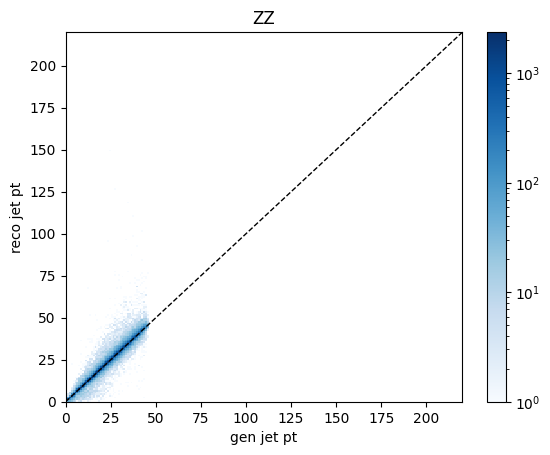

In [59]:
b = np.linspace(0,220,221)
plt.title("ZZ")
plt.hist2d(
    ak.to_numpy(to_p4(data_z["gen_jet_p4s"]).pt),
    ak.to_numpy(to_p4(data_z["reco_jet_p4s"]).pt),
    bins=(b,b),
    norm=matplotlib.colors.LogNorm(),
    cmap="Blues",
);
plt.colorbar()
plt.plot([0,220],[0,220], color="black", ls="--", lw=1.0)
plt.xlabel("gen jet pt")
plt.ylabel("reco jet pt")
plt.savefig("zz_gen_jet_reco_jet_pT.png", bbox_inches='tight')

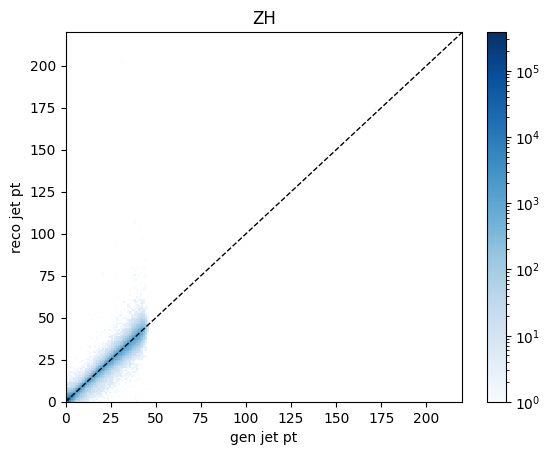

In [60]:
b = np.linspace(0,220,221)
plt.title("ZH")
plt.hist2d(
    ak.to_numpy(to_p4(data_zh["gen_jet_p4s"]).pt),
    ak.to_numpy(to_p4(data_zh["reco_jet_p4s"]).pt),
    bins=(b,b),
    norm=matplotlib.colors.LogNorm(),
    cmap="Blues",
);
plt.colorbar()
plt.plot([0,220],[0,220], color="black", ls="--", lw=1.0)
plt.xlabel("gen jet pt")
plt.ylabel("reco jet pt")
plt.savefig("zh_gen_jet_reco_jet_pT.png", bbox_inches='tight')

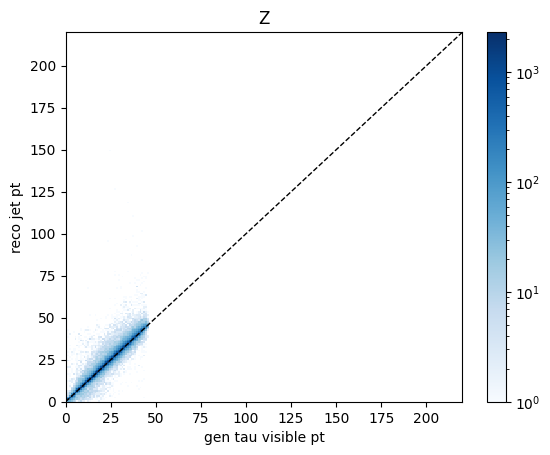

In [61]:
b = np.linspace(0,220,221)
plt.title("Z")
plt.hist2d(
    ak.to_numpy(to_p4(data_z["gen_jet_tau_p4s"]).pt),
    ak.to_numpy(to_p4(data_z["reco_jet_p4s"]).pt),
    bins=(b,b),
    norm=matplotlib.colors.LogNorm(),
    cmap="Blues",
);
plt.colorbar()
plt.plot([0,220],[0,220], color="black", ls="--", lw=1.0)
plt.xlabel("gen tau visible pt")
plt.ylabel("reco jet pt")
plt.savefig("zz_gen_tau_reco_jet_pT.png", bbox_inches='tight')

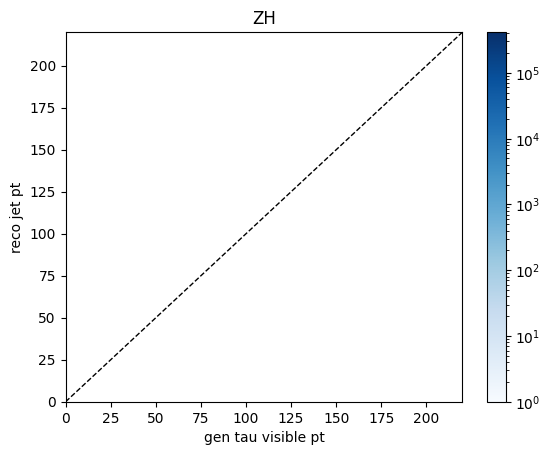

In [62]:
b = np.linspace(0,220,221)
plt.title("ZH")
plt.hist2d(
    ak.to_numpy(to_p4(data_zh["gen_jet_tau_p4s"]).pt),
    ak.to_numpy(to_p4(data_zh["reco_jet_p4s"]).pt),
    bins=(b,b),
    norm=matplotlib.colors.LogNorm(),
    cmap="Blues",
);
plt.colorbar()
plt.plot([0,220],[0,220], color="black", ls="--", lw=1.0)
plt.xlabel("gen tau visible pt")
plt.ylabel("reco jet pt")
plt.savefig("zh_gen_tau_reco_jet_pT.png", bbox_inches='tight')

In [63]:
# Δη = η_jet − η_cands same for ΔΦ

def deltaphi(phi1, phi2):
    diff = phi1 - phi2
    return np.arctan2(np.sin(diff), np.cos(diff))

# Z
z_delta_phi = deltaphi(z_reco_jet_p4s.phi, z_reco_cand_p4s.phi)
z_delta_eta = z_reco_jet_p4s.eta - z_reco_cand_p4s.eta

# ZH
zh_delta_phi = deltaphi(zh_reco_jet_p4s.phi, zh_reco_cand_p4s.phi)
zh_delta_eta = zh_reco_jet_p4s.eta - zh_reco_cand_p4s.eta

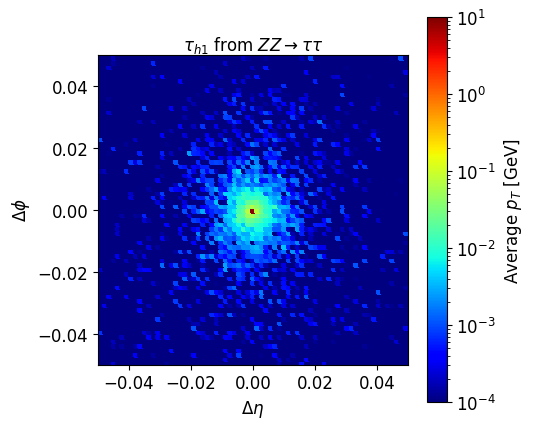

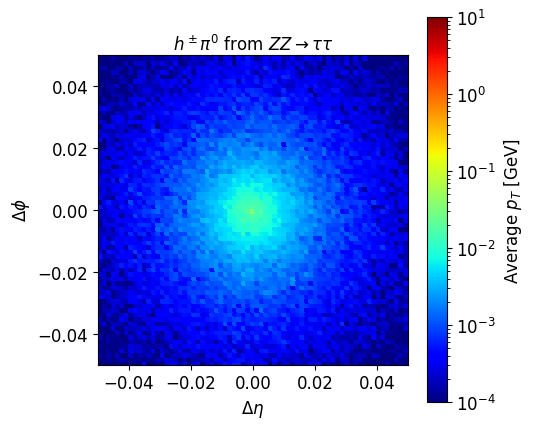

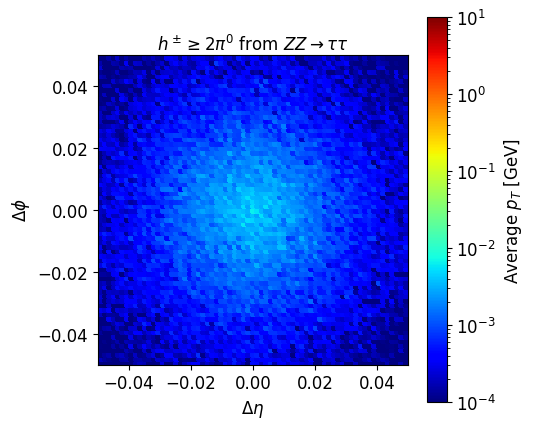

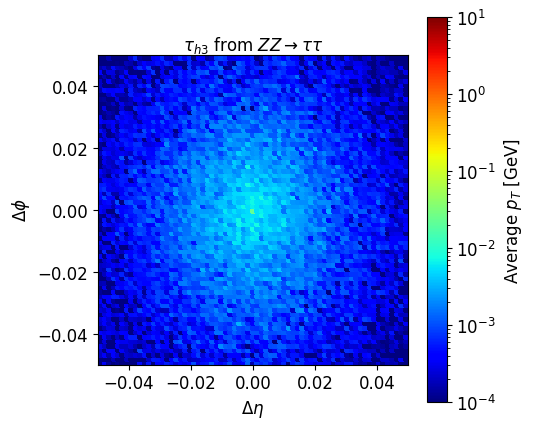

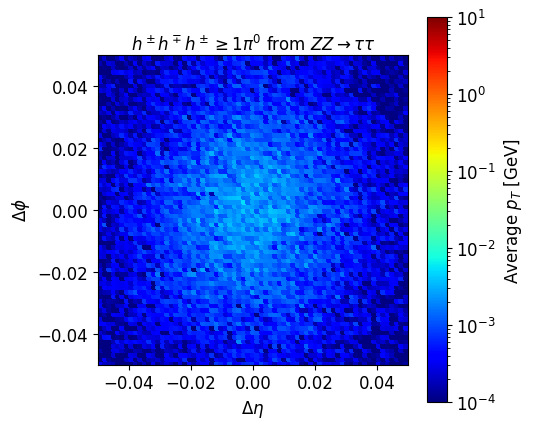

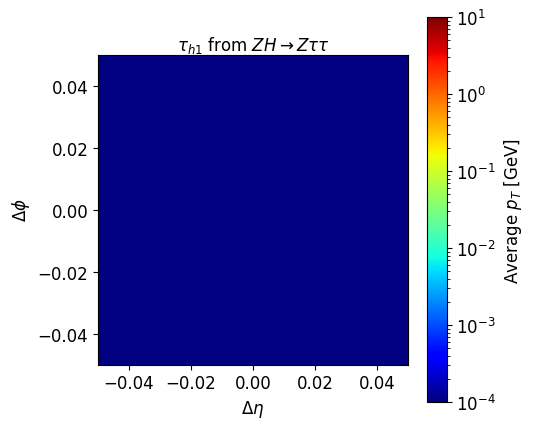

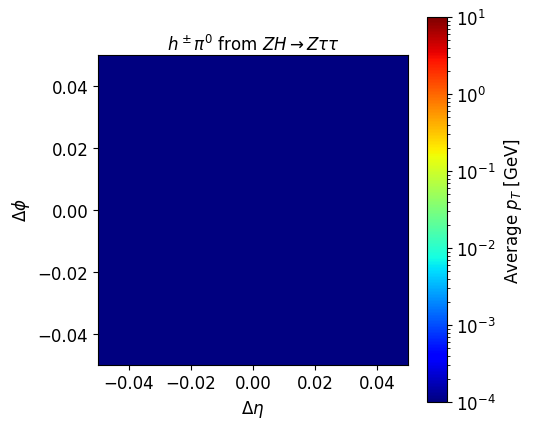

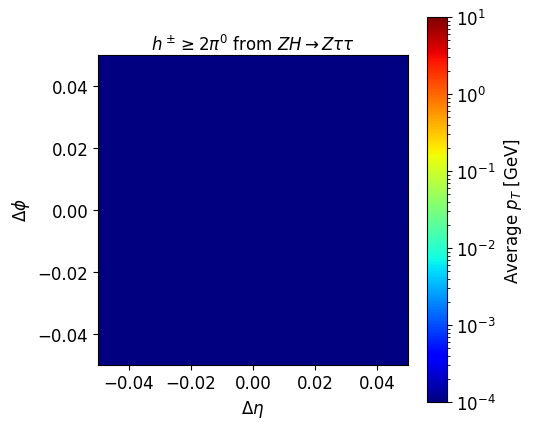

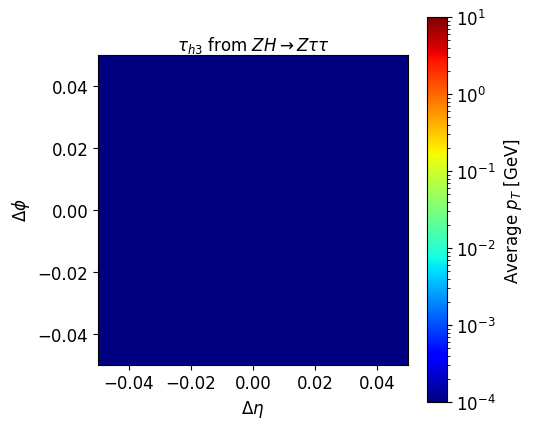

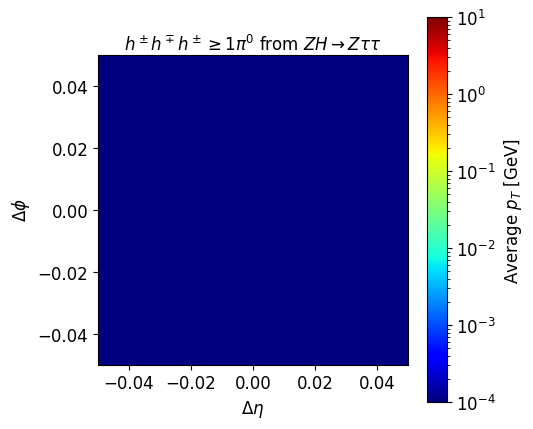

In [64]:
def plot_2d_histogram(data, mask, title, save=False, filename=None,
                      xlabel=r"$\Delta \eta$", ylabel=r"$\Delta \phi$",
                      bins=np.linspace(-0.05, 0.05, 70), cmap=matplotlib.cm.jet):
    
    # Flatten arrays and apply the mask
    delta_eta_flat = ak.to_numpy(ak.flatten(data['delta_eta'][mask]))
    delta_phi_flat = ak.to_numpy(ak.flatten(data['delta_phi'][mask]))
    pt_flat = ak.to_numpy(ak.flatten(data['pt'][mask]))
    
    # Create a new figure
    fig = plt.figure(figsize=(5, 5))
    
    # Plot the 2D histogram of delta_eta and delta_phi weighted by pT, divided by the number of particles
    hist2d = plt.hist2d(delta_eta_flat,
                        delta_phi_flat,
                        bins=bins,
                        weights=pt_flat/len(pt_flat),
                        norm=matplotlib.colors.LogNorm(vmin=0.0001, vmax=10, clip=True), 
                        cmap=cmap,
                        edgecolor='face')
    plt.xlabel(xlabel, fontsize=12) 
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title, fontsize=12, pad=3, rotation='horizontal')
    
    # Colorbar
    cbar = plt.colorbar(hist2d[3])
    cbar.set_label('Average $p_T$ [GeV]', fontsize=12)
    
    # Set tick parameters for x, y, and colorbar axes
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    cbar.ax.tick_params(labelsize=12)

    ax = plt.gca()
    ax.set_aspect('equal')
    fig.set_size_inches([5, 5],forward=True)
    
    # Save the figure if requested
    if save and filename:
        plt.savefig(filename, format='png', bbox_inches='tight')

    plt.show()

def plot_histograms_for_decay_modes(data, decay_modes_of_interest, remap_d, dataset_name, save=False):
    dataset_d = {
        "Z": r"$ZZ \rightarrow \tau\tau$",
        "ZH": r"$ZH \rightarrow Z\tau\tau$"
    }
    new_remap = dict(remap_d)
    new_remap[0] = r'$\tau_{h1}$'
    new_remap[3] = r'$\tau_{h3}$'
    # Loop through each decay mode 
    for idx_decaymode in decay_modes_of_interest:
        mask = (data['decay_mode'] == idx_decaymode)
        title = f'{new_remap[idx_decaymode]} from {dataset_d[dataset_name]}'
        filename = None
        if save:
            filename = f'jet_2D_shapes_{dataset_name}_DM{idx_decaymode}.png'
        
        plot_2d_histogram(data, mask, title, save=save, filename=filename)

# Data dictionaries
Z_data = {
    'delta_eta': z_delta_eta,
    'delta_phi': z_delta_phi,
    'pt': z_reco_cand_p4s.pt,
    'decay_mode': z_remap[0]
}

ZH_data = {
    'delta_eta': zh_delta_eta,
    'delta_phi': zh_delta_phi,
    'pt': zh_reco_cand_p4s.pt,
    'decay_mode': zh_remap[0]
}

#decay_modes_of_interest = [0, 3]
decay_modes_of_interest = [0, 1, 2, 3, 4]

# Plot and save figures for Z data
plot_histograms_for_decay_modes(Z_data, decay_modes_of_interest, remap_d, 'Z', save=True)

# Plot and save figures for ZH data
plot_histograms_for_decay_modes(ZH_data, decay_modes_of_interest, remap_d, 'ZH', save=True)

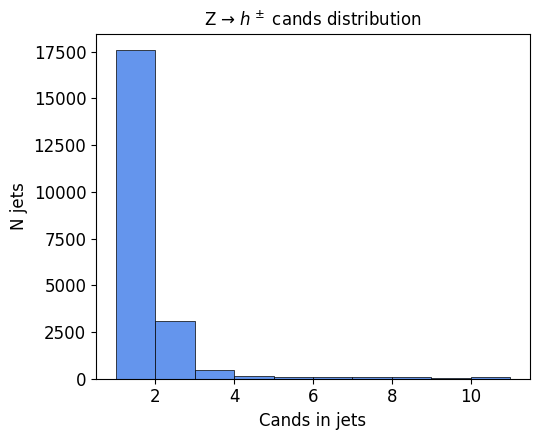

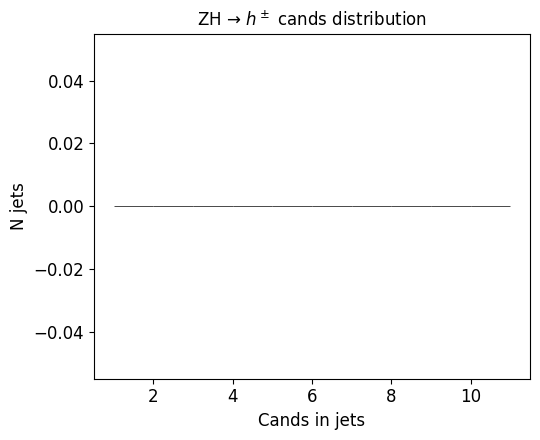

In [65]:
# Loop through each decay mode

def plot_cands_distribution(data, decay_modes_of_interest, dataset_name, filename):
    for idx_decaymode in decay_modes_of_interest:
        mask = (data['decay_mode'] == idx_decaymode)
        cands = data["reco_cand_p4s"][mask]
        jets = data["reco_jet_p4s"][mask]
        
        # List to store particle counts per jet for the current decay mode
        cands_counts = [len(c) for c in cands]
        
        # Create a new figure for each decay mode
        plt.figure(figsize=(5.5, 4.5))
        
        # Plot the histogram of particle counts per jet
        plt.hist(cands_counts, color='cornflowerblue', bins=np.linspace(1, 11, 11),
                 edgecolor='black', linewidth=0.5)
        plt.xlabel("Cands in jets", fontsize=12) 
        plt.ylabel("N jets", fontsize=12)
        plt.title(f"{dataset_name} → {remap_d[idx_decaymode]} cands distribution", fontsize=12)
        
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
       
        plt.tight_layout()
        plt.savefig(filename, bbox_inches='tight')
        plt.show()

# Assuming z_data and zh_data are dictionaries containing necessary arrays
Z_data1 = {
    'reco_cand_p4s': z_reco_cand_p4s,
    'reco_jet_p4s': z_reco_jet_p4s,
    'decay_mode': z_remap[0]
}

ZH_data1 = {
    'reco_cand_p4s': zh_reco_cand_p4s,
    'reco_jet_p4s': zh_reco_jet_p4s,
    'decay_mode': zh_remap[0]
}

decay_modes_of_interest = [0]

# Plot Z data
plot_cands_distribution(Z_data1, decay_modes_of_interest, 'Z', "Z_cands_dist.png")

# Plot ZH data
plot_cands_distribution(ZH_data1, decay_modes_of_interest, 'ZH', "ZH_cands_dist.png")

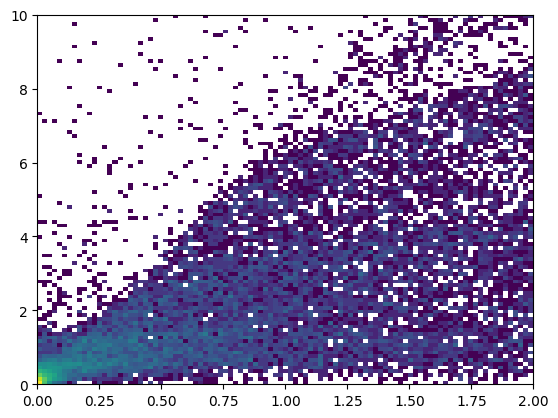

In [66]:
plt.hist2d(
    ak.to_numpy(ak.flatten(data_z["reco_cand_dz"])),
    ak.to_numpy(ak.flatten(data_z["reco_cand_dxy"])),
    bins=(np.linspace(0,2,100), np.linspace(0,10,100)), norm=matplotlib.colors.LogNorm()
);

In [67]:
def to_bh(data, bins, cumulative=False):
    h1 = bh.Histogram(bh.axis.Variable(bins))
    h1.fill(data)
    if cumulative:
        h1[:] = np.sum(h1.values()) - np.cumsum(h1)
    return h1

/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:720: RuntimeWarning: divide by zero encountered in scalar divide
  return self.flat_scale(1 / np.sum(np.diff(self.edges_1d()) * self.values()))
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:703: RuntimeWarning: invalid value encountered in multiply
  self._values *= scale
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:704: RuntimeWarning: invalid value encountered in multiply
  self.yerr_lo *= scale
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:705: RuntimeWarning: invalid value encountered in multiply
  self.yerr_hi *= scale


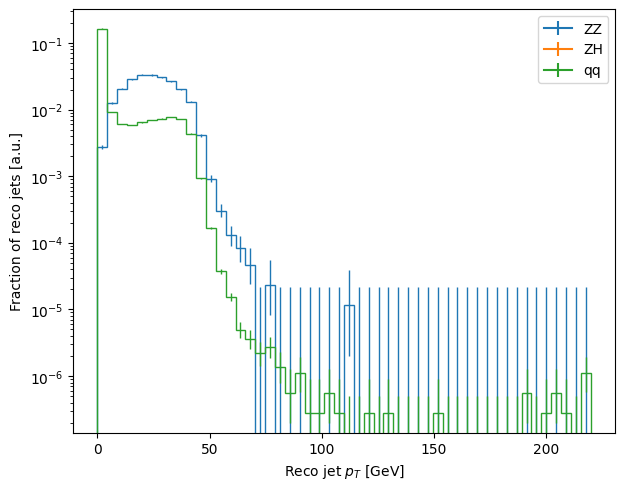

In [68]:
plt.figure(figsize=(7,5.5))
bins = np.linspace(0,220,51)

z_data_mask = data_z.gen_jet_tau_decaymode == 10
zh_data_mask = data_zh.gen_jet_tau_decaymode == 10

# Z plot
mplhep.histplot(to_bh(to_p4(data_z["reco_jet_p4s"]).pt[z_data_mask], bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="ZZ",
                density=True)
# ZH plot
mplhep.histplot(to_bh(to_p4(data_zh["reco_jet_p4s"]).pt[zh_data_mask], bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="ZH",
                density=True)
# qq plot
mplhep.histplot(to_bh(to_p4(data_qq["reco_jet_p4s"]).pt, bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="qq",
                density=True)

plt.legend(loc="best")
plt.yscale("log")

plt.xlabel("Reco jet $p_T$ [GeV]")
plt.ylabel("Fraction of reco jets [a.u.]");

# plt.savefig("reco_jet_pt_dm10.pdf", bbox_inches='tight')

NameError: name 'legend_obj' is not defined

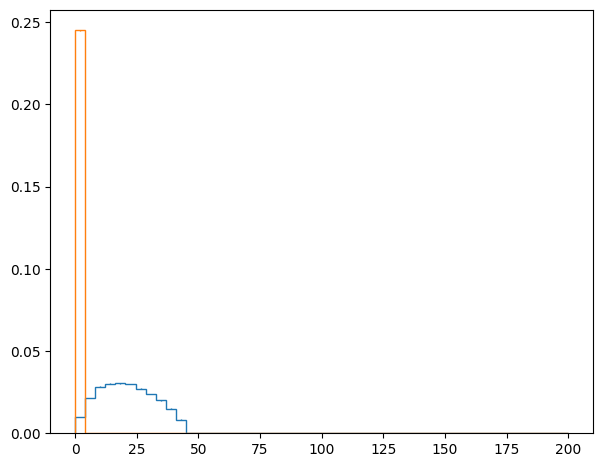

In [69]:
plt.figure(figsize=(7,5.5))
bins = np.linspace(0,200,50)


# Z plot
mplhep.histplot(to_bh(to_p4(data_z["gen_jet_tau_p4s"]).pt, bins=bins),
                histtype="step",
                lw=1, flow="sum",
                label="Z",
                density=True)
# ZH plot
mplhep.histplot(to_bh(to_p4(data_zh["gen_jet_tau_p4s"]).pt, bins=bins),
                histtype="step",
                lw=1, flow="sum",
                label="ZH",
                density=True)


legend_obj._legend_box.align = "right"
plt.yscale("log")
plt.xlabel("GenVisTau $p_T$ [GeV]")
plt.ylabel("Entries");
plt.title("GenVisTau pT distribution")

plt.savefig("gen_tau_visible_pt.png", bbox_inches='tight')

/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:720: RuntimeWarning: divide by zero encountered in scalar divide
  return self.flat_scale(1 / np.sum(np.diff(self.edges_1d()) * self.values()))
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:703: RuntimeWarning: invalid value encountered in multiply
  self._values *= scale
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:704: RuntimeWarning: invalid value encountered in multiply
  self.yerr_lo *= scale
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:705: RuntimeWarning: invalid value encountered in multiply
  self.yerr_hi *= scale


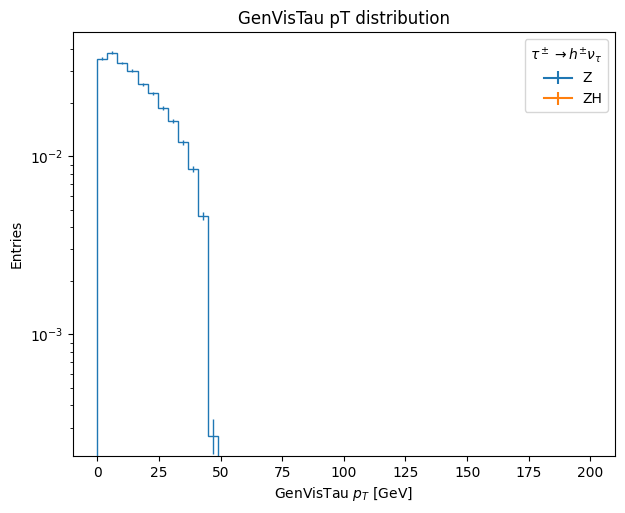

In [70]:
plt.figure(figsize=(7,5.5))
bins = np.linspace(0,200,50)


z_data_mask = data_z.gen_jet_tau_decaymode == 0
zh_data_mask = data_zh.gen_jet_tau_decaymode == 0
# Z plot
mplhep.histplot(to_bh(to_p4(data_z["gen_jet_tau_p4s"]).pt[z_data_mask], bins=bins),
                histtype="step",
                lw=1, flow="sum",
                label="Z",
                density=True)
# ZH plot
mplhep.histplot(to_bh(to_p4(data_zh["gen_jet_tau_p4s"]).pt[zh_data_mask], bins=bins),
                histtype="step",
                lw=1, flow="sum",
                label="ZH",
                density=True)

legend_obj = plt.legend(title=r"$\tau^\pm \rightarrow h^{\pm}\nu_\tau$", loc="upper right")
legend_obj._legend_box.align = "right"
plt.yscale("log")
plt.xlabel("GenVisTau $p_T$ [GeV]")
plt.ylabel("Entries");
plt.title("GenVisTau pT distribution")

plt.savefig("gen_tau_visible_pt_dm0.png", bbox_inches='tight')

/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:720: RuntimeWarning: divide by zero encountered in scalar divide
  return self.flat_scale(1 / np.sum(np.diff(self.edges_1d()) * self.values()))
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:703: RuntimeWarning: invalid value encountered in multiply
  self._values *= scale
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:704: RuntimeWarning: invalid value encountered in multiply
  self.yerr_lo *= scale
/opt/conda/lib/python3.11/site-packages/mplhep/utils.py:705: RuntimeWarning: invalid value encountered in multiply
  self.yerr_hi *= scale


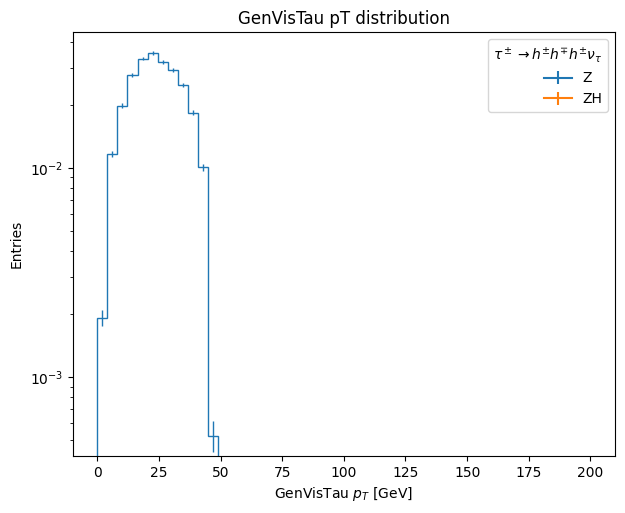

In [71]:
fig = plt.figure(figsize=(7,5.5))
bins = np.linspace(0,200,50)


z_data_mask = data_z.gen_jet_tau_decaymode == 10
zh_data_mask = data_zh.gen_jet_tau_decaymode == 10
# Z plot
mplhep.histplot(to_bh(to_p4(data_z["gen_jet_tau_p4s"]).pt[z_data_mask], bins=bins),
                histtype="step",
                lw=1, flow="sum",
                label="Z",
                density=True)
# ZH plot
mplhep.histplot(to_bh(to_p4(data_zh["gen_jet_tau_p4s"]).pt[zh_data_mask], bins=bins),
                histtype="step",
                lw=1, flow="sum",
                label="ZH",
                density=True)

legend_obj = plt.legend(title=r"$\tau^\pm \rightarrow h^{\pm}h^{\mp}h^{\pm}\nu_\tau$", loc="upper right")
legend_obj._legend_box.align = "right"
plt.yscale("log")
plt.xlabel("GenVisTau $p_T$ [GeV]")
plt.title("GenVisTau pT distribution")
plt.ylabel("Entries");

plt.savefig("gen_tau_visible_pt_dm10.png", bbox_inches='tight')

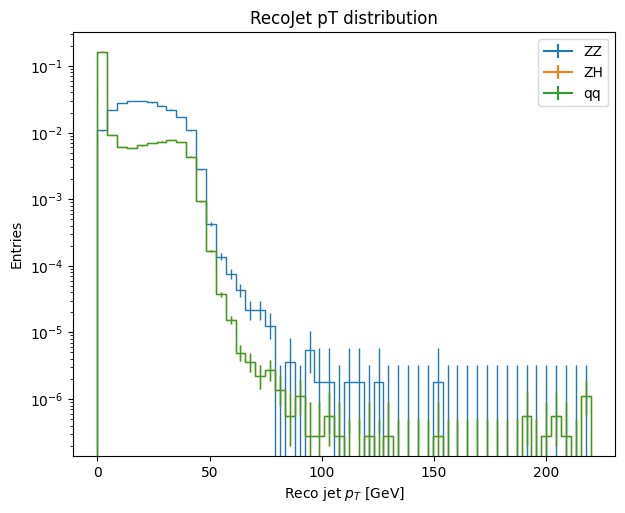

In [72]:
plt.figure(figsize=(7,5.5))
bins = np.linspace(0,220,51)

# Z plot
mplhep.histplot(to_bh(to_p4(data_z["reco_jet_p4s"]).pt, bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="ZZ",
                density=True)
# ZH plot
mplhep.histplot(to_bh(to_p4(data_zh["reco_jet_p4s"]).pt, bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="ZH",
                density=True)
# qq plot
mplhep.histplot(to_bh(to_p4(data_qq["reco_jet_p4s"]).pt, bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="qq",
                density=True)

plt.legend(loc="best")
plt.yscale("log")
plt.title("RecoJet pT distribution")
plt.xlabel("Reco jet $p_T$ [GeV]")
plt.ylabel("Entries");

plt.savefig("reco_jet_pt.png", bbox_inches='tight')

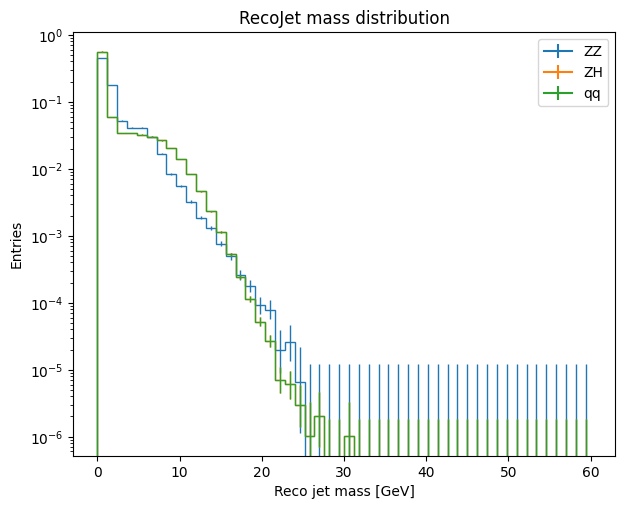

In [73]:
plt.figure(figsize=(7,5.5))
bins = np.linspace(0,60,51)

# Z plot
mplhep.histplot(to_bh(to_p4(data_z["reco_jet_p4s"]).mass, bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="ZZ",
                density=True)
# ZH plot
mplhep.histplot(to_bh(to_p4(data_zh["reco_jet_p4s"]).mass, bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="ZH",
                density=True)
# qq plot
mplhep.histplot(to_bh(to_p4(data_qq["reco_jet_p4s"]).mass, bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="qq",
                density=True)

plt.legend(loc="best")
plt.yscale("log")
plt.title("RecoJet mass distribution")
plt.xlabel("Reco jet mass [GeV]")
plt.ylabel("Entries");

plt.savefig("reco_jet_mass.png", bbox_inches='tight')

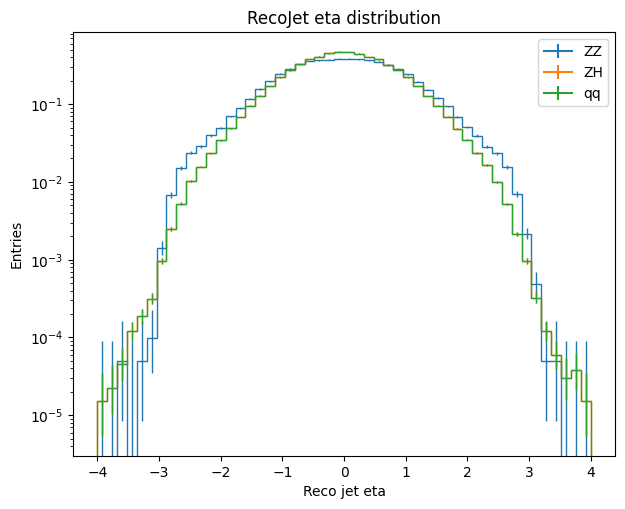

In [74]:
plt.figure(figsize=(7,5.5))
bins = np.linspace(-4,4,51)

# Z plot
mplhep.histplot(to_bh(to_p4(data_z["reco_jet_p4s"]).eta, bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="ZZ",
                density=True)
# ZH plot
mplhep.histplot(to_bh(to_p4(data_zh["reco_jet_p4s"]).eta, bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="ZH",
                density=True)
# qq plot
mplhep.histplot(to_bh(to_p4(data_qq["reco_jet_p4s"]).eta, bins=bins),
                histtype="step",
                lw=1,
                flow="sum",
                label="qq",
                density=True)

plt.legend(loc="best")
plt.yscale("log")
plt.title("RecoJet eta distribution")
plt.xlabel("Reco jet eta")
plt.ylabel("Entries");

plt.savefig("reco_jet_eta.png", bbox_inches='tight')

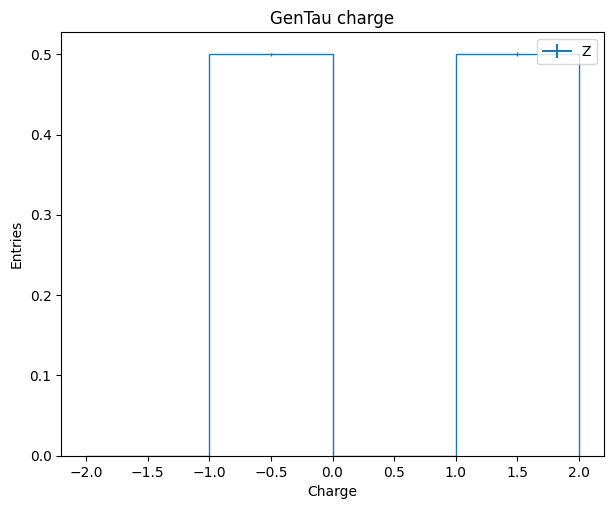

In [76]:
fig = plt.figure(figsize=(7,5.5))
bins = np.linspace(-2,2,5)

# Z plot
mplhep.histplot(to_bh(z_gen_tau_charge, bins=bins),
                histtype="step",
                lw=1, flow="sum",
                label="Z",
                density=True)
# # ZH plot
# mplhep.histplot(to_bh(zh_gen_tau_charge, bins=bins),
#                 histtype="step",
#                 lw=1, flow="sum",
#                 label="ZH",
#                 density=True)

legend_obj._legend_box.align = "right"
# plt.yscale("log")
plt.legend(loc="upper right")
plt.xlabel("Charge")
plt.title("GenTau charge")
plt.ylabel("Entries");

plt.savefig("gen_tau_charge.png", bbox_inches='tight')

In [78]:
ak.num(z_gen_tau_charge == 1)

AxisError: axis=1 exceeds the depth of this array (1)

In [ ]:
fig = plt.figure(figsize=(7,5.5))
bins = np.linspace(0,2,30)

# Z plot
mplhep.histplot(to_bh(z_reco_jet_p4s.pt/z_gen_tau_p4s.pt, bins=bins),
                histtype="step",
                lw=1, flow="none",
                label="Z",
                density=True)
# ZH plot
mplhep.histplot(to_bh(zh_reco_jet_p4s.pt/zh_gen_tau_p4s.pt, bins=bins),
                histtype="step",
                lw=1, flow="none",
                label="ZH",
                density=True)

plt.legend(loc="best")
# plt.yscale("log")
plt.title("pT response")
plt.xlabel("RecoJet / GenVisTau")
plt.ylabel("Entries");

plt.savefig("pt_response.png", bbox_inches='tight')

In [ ]:
def plot_cands_distribution(data, dataset_name, filename):

    cands = data["reco_cand_p4s"]
    jets = data["reco_jet_p4s"]
    
    # List to store particle counts per jet for the current decay mode
    cands_counts = [len(c) for c in cands]
    
    # Create a new figure for each decay mode
    plt.figure(figsize=(5.5, 4.5))
    
    # Plot the histogram of particle counts per jet
    plt.hist(cands_counts, color='cornflowerblue', bins=np.linspace(1, 11, 11),
             edgecolor='black', linewidth=0.5)
    plt.xlabel("Cands in jets", fontsize=12) 
    plt.ylabel("N jets", fontsize=12)
    plt.title(f"{dataset_name} cands distribution", fontsize=12)
    
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
   
    plt.tight_layout()
    # plt.savefig(filename, bbox_inches='tight')
    plt.show()


qq_data1 = {
    'reco_cand_p4s': qq_reco_cand_p4s,
    'reco_jet_p4s': qq_reco_jet_p4s,
}

# Plot Z data
plot_cands_distribution(qq_data1, 'qq', "qq_cands_dist.png")

In [ ]:
mask = qq_reco_jet_p4s.pt > 10
plot_cands_distribution(
    {
        "reco_cand_p4s": qq_reco_cand_p4s[mask],
        "reco_jet_p4s": qq_reco_jet_p4s[mask],
    },
    "qq (pT > 10 GeV)",
    "qq_cands_pt10.png"
)

In [326]:
data_qq["reco_cand_pdg"][mask]

<Array [[130, 211, 11, 211, ..., 22, 22, 130], ...] type='205218 * var * int64'>

In [351]:
n_cands = ak.num(data_qq["reco_cand_p4s"])
# n_cands = ak.num(data_qq["reco_cand_p4s"][mask])
one_cand_mask = (n_cands == 1)
one_cand_pdgs = ak.flatten(data_qq["reco_cand_pdg"][one_cand_mask])
one_cand_pts = ak.flatten(to_p4(data_qq["reco_cand_p4s"]).pt[one_cand_mask])
# one_cand_pdgs = ak.flatten(data_qq["reco_cand_pdg"][mask][one_cand_mask])

In [349]:
unique, counts = np.unique(one_cand_pdgs, return_counts=True)
for u, c in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"PDG {u:>4}: {c}")

PDG   22: 156713
PDG  211: 88106
PDG  130: 19723
PDG   11: 10610
PDG   13: 118


In [97]:
chargearray = ak.flatten(data_z["gen_jet_tau_charge"], axis = -1)

In [98]:
unique, counts = np.unique(chargearray, return_counts=True)
for u, c in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"charge {u:>4}: {c}")

charge  1.0: 63474.0
charge -1.0: 63409.0
